# Clustering Algorithms

## What is Clustering?
Clustering is an **unsupervised learning** task that groups similar data points together without labeled examples.

Applications: customer segmentation, anomaly detection, document grouping, image compression, gene expression analysis.

---

## 1. K-Means Clustering

**Objective**: Minimize within-cluster sum of squares (WCSS):

$$J = \sum_{k=1}^{K} \sum_{x_i \in C_k} \|x_i - \mu_k\|^2$$

**Algorithm** (Lloyd's algorithm):
1. Initialize $K$ centroids $\mu_1, \ldots, \mu_K$
2. **Assign**: $C_k = \{x_i : k = \arg\min_j \|x_i - \mu_j\|^2\}$
3. **Update**: $\mu_k = \frac{1}{|C_k|}\sum_{x_i \in C_k} x_i$
4. Repeat until convergence

**K-Means++** (smarter initialization): Choose centroids with probability proportional to $d(x, \text{nearest centroid})^2$ → faster convergence, better solutions.

**Choosing K**: 
- Elbow method: plot WCSS vs $K$, find the elbow
- Silhouette analysis
- Gap statistic: $\text{Gap}(K) = E[\log W_K] - \log W_K$

---

## 2. Silhouette Score

Measures how similar a point is to its cluster vs. other clusters:

$$s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}$$

- $a(i)$: mean distance to points in same cluster
- $b(i)$: mean distance to points in nearest other cluster
- Range: $[-1, 1]$ higher is better, $>0.5$ is good

---

## 3. DBSCAN

**Density-Based Spatial Clustering** finds clusters of arbitrary shape.

Parameters: $\epsilon$ (neighborhood radius), `min_samples` (core point threshold)

Point types:
- **Core point**: has $\geq$ `min_samples` points within $\epsilon$
- **Border point**: within $\epsilon$ of a core point but not core itself
- **Noise point**: neither core nor border

**Advantage**: discovers clusters of arbitrary shape, identifies outliers automatically
**Disadvantage**: struggles with varying densities

**HDBSCAN** (Hierarchical DBSCAN): automatically selects $\epsilon$, handles varying densities. State of the art.

---

## 4. Hierarchical Clustering

Builds a **dendrogram** tree of clusters.

### Agglomerative (bottom-up):
1. Start: each point is its own cluster
2. Merge closest pair of clusters
3. Repeat until one cluster

**Linkage methods** (how to measure distance between clusters):

| Method | Formula | Properties |
|--------|---------|------------|
| Single | $\min_{x\in A, y\in B} d(x,y)$ | Can chain, finds elongated |
| Complete | $\max_{x\in A, y\in B} d(x,y)$ | Compact clusters |
| Average | $\frac{1}{|A||B|}\sum d(x,y)$ | Between single and complete |
| **Ward** | $\Delta J = \frac{|A||B|}{|A|+|B|}\|\mu_A - \mu_B\|^2$ | Minimizes WCSS, best usually |

---

## 5. Gaussian Mixture Models (GMM)

Assumes data is generated from $K$ Gaussian distributions:

$$p(x) = \sum_{k=1}^{K} \pi_k \mathcal{N}(x|\mu_k, \Sigma_k)$$

Where $\pi_k$ are mixing coefficients ($\sum \pi_k = 1$).

**EM Algorithm**:
- **E-step**: Compute responsibilities: $r_{ik} = \frac{\pi_k \mathcal{N}(x_i|\mu_k,\Sigma_k)}{\sum_j \pi_j \mathcal{N}(x_i|\mu_j,\Sigma_j)}$
- **M-step**: Update $\pi_k, \mu_k, \Sigma_k$ using responsibilities

**GMM vs K-Means**: Soft assignments, handles elliptical clusters, probabilistic framework.

---

## 6. Other Clustering Algorithms

| Algorithm | Idea | Best For |
|-----------|------|----------|
| **Mean-Shift** | Shift to mean of neighborhood | Unknown K, arbitrary shape |
| **Spectral** | Cluster in eigenspace of graph Laplacian | Non-convex clusters |
| **Affinity Propagation** | Message passing, all points are potential exemplars | Unknown K, small datasets |
| **OPTICS** | Ordering points to identify cluster structure | Varying density |
| **Mini-Batch K-Means** | SGD version of K-Means | Large datasets |
| **Birch** | Tree-based incremental | Streaming, large data |

---

## 7. Cluster Validity Metrics

**Internal** (no ground truth):
- Silhouette score: $[-1, 1]$ (higher better)
- Davies-Bouldin Index: $DBI = \frac{1}{K}\sum_i \max_{j\neq i}\left(\frac{s_i + s_j}{d(c_i, c_j)}\right)$ (lower better)
- Calinski-Harabasz: ratio of between-cluster to within-cluster variance (higher better)

**External** (with ground truth):
- Adjusted Rand Index (ARI)
- Normalized Mutual Information (NMI)
- Fowlkes-Mallows score

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import (
    KMeans, DBSCAN, AgglomerativeClustering, SpectralClustering,
    MeanShift, AffinityPropagation, MiniBatchKMeans, OPTICS, Birch
)
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
)
from sklearn.preprocessing import StandardScaler
np.random.seed(42)

X_blobs, y_true = make_blobs(n_samples=500, centers=4, cluster_std=0.8, random_state=42)
X_moons, _ = make_moons(n_samples=300, noise=0.1, random_state=42)
X_circles, _ = make_circles(n_samples=300, noise=0.05, factor=0.5, random_state=42)

## K-Means from Scratch

In [2]:
class KMeansScratch:
    def __init__(self, K=4, max_iter=300, tol=1e-4, init='kmeans++'):
        self.K = K
        self.max_iter = max_iter
        self.tol = tol
        self.init = init

    def _init_centroids(self, X):
        if self.init == 'random':
            idx = np.random.choice(len(X), self.K, replace=False)
            return X[idx].copy()
        # KMeans++ initialization
        centroids = [X[np.random.randint(len(X))]]
        for _ in range(self.K - 1):
            dists = np.array([min(np.linalg.norm(x - c)**2 for c in centroids) for x in X])
            probs = dists / dists.sum()
            centroids.append(X[np.random.choice(len(X), p=probs)])
        return np.array(centroids)

    def fit(self, X):
        self.centroids = self._init_centroids(X)
        self.inertia_history = []
        for _ in range(self.max_iter):
            # Assignment step
            dists = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            self.labels_ = np.argmin(dists, axis=1)
            # Update step
            new_centroids = np.array([X[self.labels_ == k].mean(axis=0) for k in range(self.K)])
            # Inertia (WCSS)
            self.inertia_ = sum(np.sum((X[self.labels_ == k] - new_centroids[k])**2) for k in range(self.K))
            self.inertia_history.append(self.inertia_)
            if np.allclose(new_centroids, self.centroids, atol=self.tol): break
            self.centroids = new_centroids
        return self

    def predict(self, X):
        dists = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(dists, axis=1)


km_scratch = KMeansScratch(K=4).fit(X_blobs)
print(f'Scratch K-Means Inertia: {km_scratch.inertia_:.2f}')
print(f'Scratch K-Means ARI: {adjusted_rand_score(y_true, km_scratch.labels_):.4f}')

Scratch K-Means Inertia: 607.29
Scratch K-Means ARI: 1.0000


## Elbow Method & Silhouette Analysis

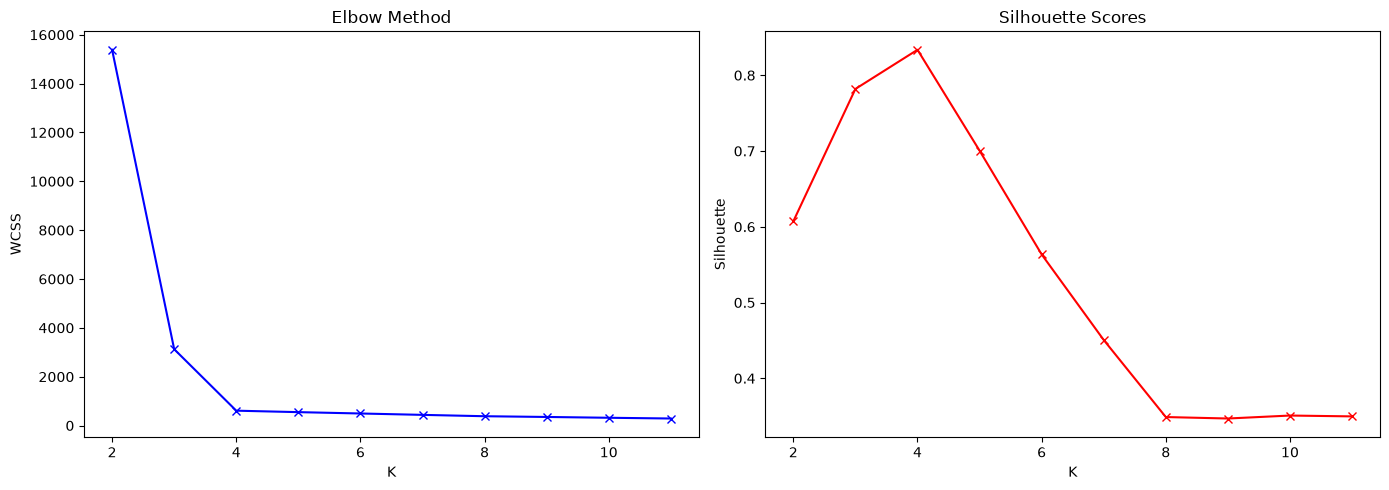

In [3]:
inertias, sil_scores = [], []
K_range = range(2, 12)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_blobs)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_blobs, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(K_range, inertias, 'bx-')
axes[0].set_xlabel('K'); axes[0].set_ylabel('WCSS'); axes[0].set_title('Elbow Method')
axes[1].plot(K_range, sil_scores, 'rx-')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Silhouette'); axes[1].set_title('Silhouette Scores')
plt.tight_layout(); plt.show()

## Algorithm Comparison on Different Datasets

/home/dell/Desktop/AI_Tasks/Additional_Data/AI/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/dell/Desktop/AI_Tasks/Additional_Data/AI/zero-to-ai-engineer/.venv/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:325: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


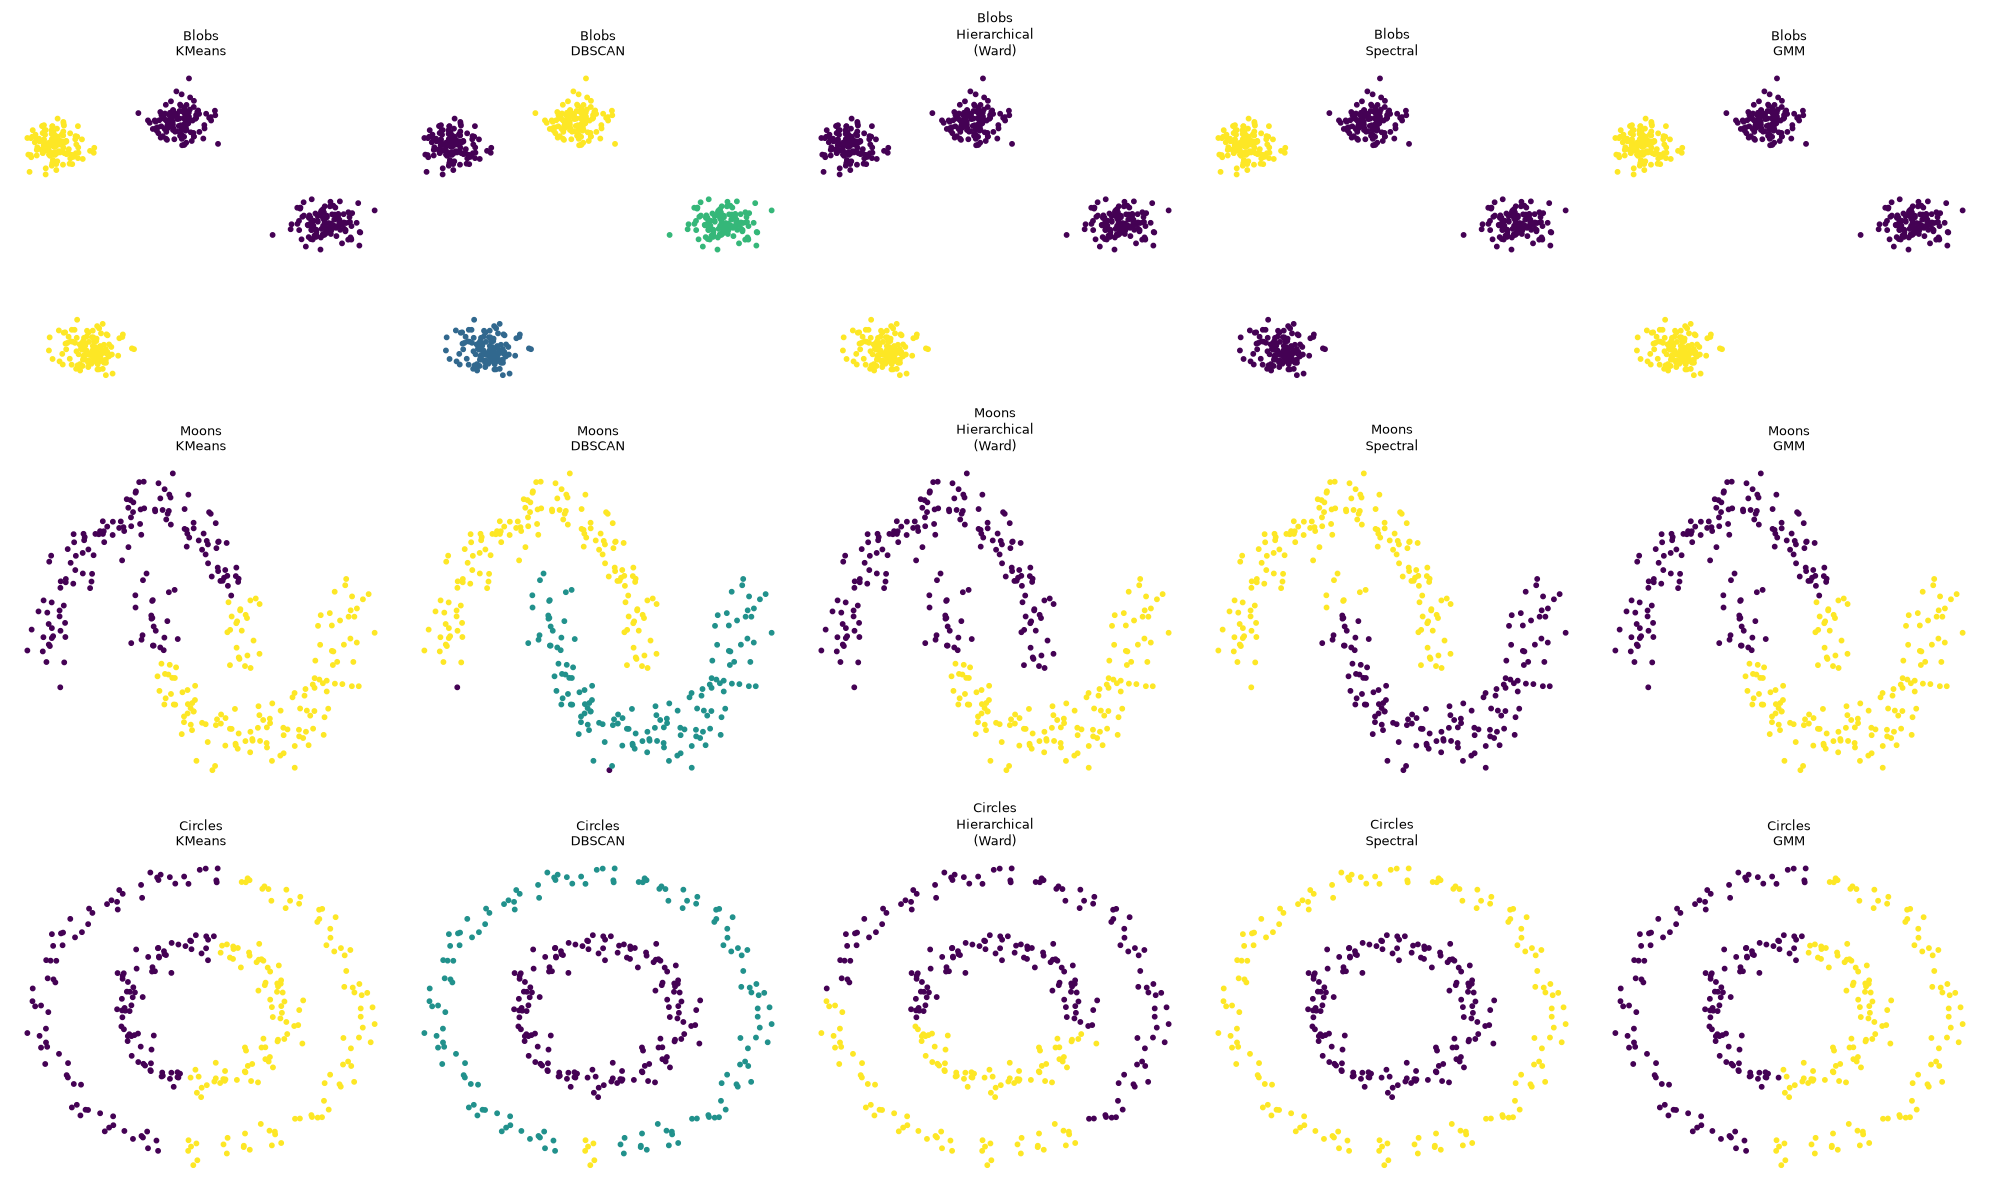

In [4]:
datasets = [('Blobs', X_blobs), ('Moons', X_moons), ('Circles', X_circles)]
algorithms = [
    ('KMeans', KMeans(n_clusters=2, random_state=42)),
    ('DBSCAN', DBSCAN(eps=0.3, min_samples=5)),
    ('Hierarchical\n(Ward)', AgglomerativeClustering(n_clusters=2)),
    ('Spectral', SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)),
    ('GMM', GaussianMixture(n_components=2, random_state=42))
]

fig, axes = plt.subplots(len(datasets), len(algorithms), figsize=(20, 12))
for i, (ds_name, X_ds) in enumerate(datasets):
    X_s = StandardScaler().fit_transform(X_ds)
    for j, (name, algo) in enumerate(algorithms):
        algo_clone = type(algo)(**algo.get_params())
        if hasattr(algo_clone, 'fit_predict'):
            labels = algo_clone.fit_predict(X_s)
        else:
            algo_clone.fit(X_s)
            labels = algo_clone.predict(X_s)
        axes[i][j].scatter(X_s[:, 0], X_s[:, 1], c=labels, cmap='viridis', s=10)
        axes[i][j].set_title(f'{ds_name}\n{name}', fontsize=9)
        axes[i][j].axis('off')
plt.tight_layout(); plt.show()

## Additional Learning Resources

### Papers
- 📄 [DBSCAN: A Density-Based Algorithm for Discovering Clusters (Ester et al. 1996)](https://www.aaai.org/Papers/KDD/1996/KDD96-037.pdf)
- 📄 [HDBSCAN: Hierarchical Density-Based Clustering](https://link.springer.com/chapter/10.1007/978-3-642-37456-2_14)
- 📄 [A Tutorial on Spectral Clustering (Von Luxburg 2007)](https://arxiv.org/abs/0711.0189)
- 📄 [Gaussian Mixtures & EM Algorithm (Bishop PRML Chapter 9)](https://www.microsoft.com/en-us/research/uploads/prod/2006/01/Bishop-Pattern-Recognition-and-Machine-Learning-2006.pdf)

### Videos
- 🎥 [StatQuest: K-Means Clustering](https://www.youtube.com/watch?v=4b5d3muPQmA)
- 🎥 [StatQuest: Hierarchical Clustering](https://www.youtube.com/watch?v=7xHsRkOdVwo)
- 🎥 [StatQuest: DBSCAN](https://www.youtube.com/watch?v=RDZUdRSDOok)
- 🎥 [StatQuest: GMM & EM Algorithm](https://www.youtube.com/watch?v=REypj2sy_5U)

### Documentation
- 📚 [Scikit-Learn Clustering](https://scikit-learn.org/stable/modules/clustering.html)
- 📚 [HDBSCAN Documentation](https://hdbscan.readthedocs.io/)